In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/machine learning/praktikum/praktikum11"

## 1. Import Library
Pada bagian ini mengimpor semua library yang diperlukan untuk analisis clustering.

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 2. Load Dataset Iris
Memuat dataset Iris bawaan scikit-learn ke dalam DataFrame.

In [5]:
df = pd.read_csv(path + '/data/Iris.csv' , sep=',' )
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Preprocessing

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(df.iloc[:, :4])

## 4. K-Means Clustering

In [7]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X)
silhouette_kmeans = silhouette_score(X, df['Cluster_KMeans'])
silhouette_kmeans

np.float64(0.42560414986156675)

## 5. Confusion Matrix

In [10]:
from sklearn.preprocessing import LabelEncoder

# Ensure 'SpeciesEncoded' column exists before calculating confusion matrix
# This code is being moved/duplicated to ensure execution order for the fix
if 'SpeciesEncoded' not in df.columns:
    le = LabelEncoder()
    df["SpeciesEncoded"] = le.fit_transform(df["Species"])

cm = confusion_matrix(df['SpeciesEncoded'], df['Cluster_KMeans'])
cm

array([[ 0,  1, 49],
       [10, 40,  0],
       [43,  7,  0]])

## 6. Penentuan eps & min_samples
Menggunakan k-distance plot untuk menentukan nilai eps DBSCAN.

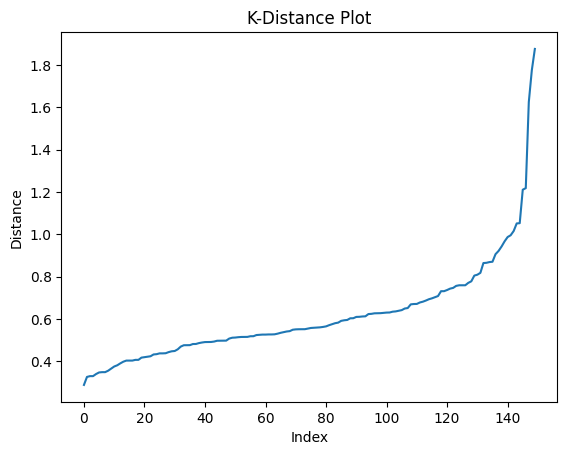

In [16]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:,4])

plt.plot(distances)
plt.title('K-Distance Plot')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()

## 7. Implementasi DBSCAN
Menjalankan clustering berbasis densitas.

In [17]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X)
df['Cluster_DBSCAN'].value_counts()

,count
Cluster_DBSCAN,
0,42
1,41
-1,34
2,33


## 8. Evaluasi DBSCAN

In [18]:
labels_db = df['Cluster_DBSCAN']
if len(set(labels_db)) > 1 and -1 not in set(labels_db):
    silhouette_score(X, labels_db)
else:
    'Silhouette tidak dapat dihitung'

## 9. Visualisasi K-Means

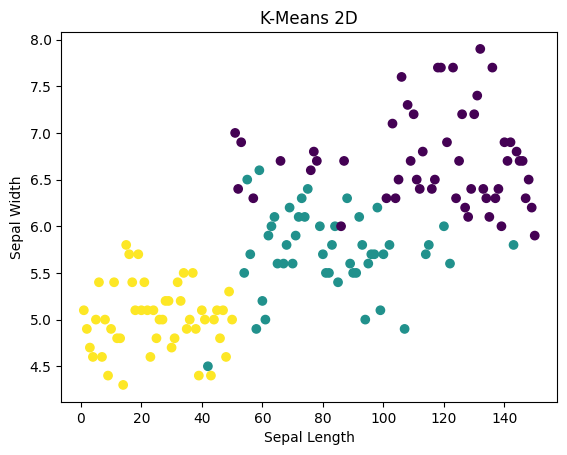

In [19]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['Cluster_KMeans'])
plt.title('K-Means 2D')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()

## 10. Visualisasi DBSCAN

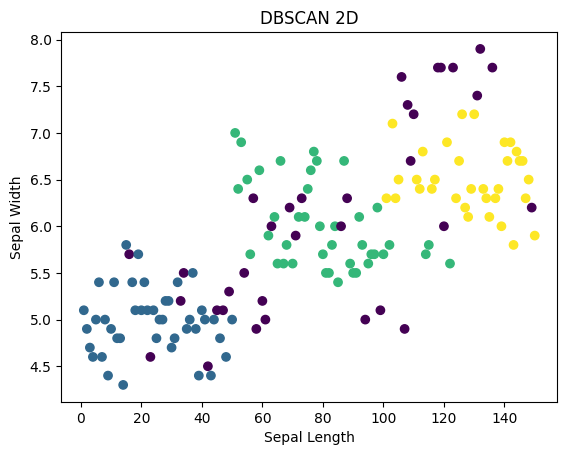

In [20]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['Cluster_DBSCAN'])
plt.title('DBSCAN 2D')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()

## 11. Analisis Persebaran Cluster dan Noise

In [21]:
unique_labels = set(df['Cluster_DBSCAN'])
counts = {label: sum(df['Cluster_DBSCAN']==label) for label in unique_labels}
counts

{0: 42, 1: 41, 2: 33, -1: 34}

## 12. Visualisasi Peta GPS (Contoh Data)

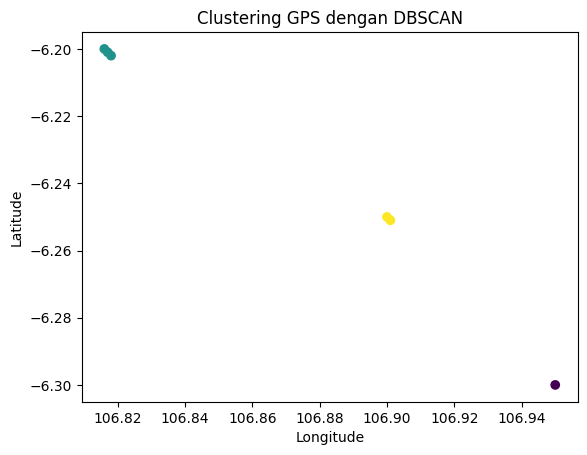

In [22]:
gps = pd.DataFrame({
    'lat': [-6.200,-6.201,-6.202,-6.250,-6.251,-6.300],
    'lon': [106.816,106.817,106.818,106.900,106.901,106.950]
})

gps_scaled = scaler.fit_transform(gps[['lat','lon']])
db_gps = DBSCAN(eps=0.5, min_samples=2)
gps['Cluster_GPS'] = db_gps.fit_predict(gps_scaled)

plt.scatter(gps['lon'], gps['lat'], c=gps['Cluster_GPS'])
plt.title('Clustering GPS dengan DBSCAN')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()